In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, roc_auc_score, roc_curve, average_precision_score, precision_recall_curve
from sklearn.preprocessing import LabelBinarizer
import joblib
from sklearn.model_selection import StratifiedKFold
import matplotlib
import os
import time

from functions_for_evaluation import AUCAUPkfold_from_file
from scoring import classify_db

matplotlib.rcParams['font.serif'] = 'Times New Roman'
matplotlib.rcParams['font.family'] = "serif"
matplotlib.rcParams['font.size'] = 15

In [2]:
def annotated_scatter_xy(
    x,
    y,
    xlabel="X",
    ylabel="Y",
    title=None,
    alpha=0.30,
    s=30,
    figsize=(6.5, 5),
    add_identity=False,
    add_corr=True
):
    """
    x, y can be:
    - lists
    - numpy arrays
    - pandas Series
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Remove missing values consistently
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        x,
        y,
        s=s,
        alpha=alpha,
        edgecolors="none"
    )

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)

    if title is not None:
        ax.set_title(title, fontsize=13, pad=12)

    # Optional y=x reference line
    if add_identity:
        lo = min(np.min(x), np.min(y))
        hi = max(np.max(x), np.max(y))
        ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=2, color='red')

    # Optional Pearson correlation
    if add_corr and len(x) > 1:
        r = np.corrcoef(x, y)[0, 1]
        ax.text(
            0.05,
            0.95,
            f"Pearson r = {r:.4f}\nN = {len(x):,}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=11,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none")
        )

    ax.grid(True, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

# Import USDA Manual-Labeled Data 
### 58 key nutrients reported across different NHANES/FNDDS cycles

The trained classifiers use `pythonlabel`, defined as:

`pythonlabel = novaclass - 1`

Therefore, the model class order is:

- `0` = NOVA 1
- `1` = NOVA 2
- `2` = NOVA 3
- `3` = NOVA 4

Rows with `novaclass = 0` become `pythonlabel = -1` and are excluded from model training.

### Definition of FPro

The trained classifiers output, for each food item $k$, a probability vector $p^k = (p_1^k, p_2^k, p_3^k, p_4^k)$, where $p_i^k$ is the predicted probability that item $k$ belongs to NOVA class $i$. Formally, FPro is defined as the orthogonal projection of the food’s class-probability vector $p^k$ onto the line within the probability simplex that extends from the minimally processed vertex $(1,0,0,0)$ to the ultra-processed vertex $(0,0,0,1)$. The score for item $k$ is therefore given by

$\mathrm{FPro}_k = \frac{1 - p_1^k + p_4^k}{2}.$

This formulation maps the minimally processed vertex to $\mathrm{FPro}=0$ and the ultra-processed vertex to $\mathrm{FPro}=1$.

### Random-forest hyperparameters and rationale

We used a fixed random-forest configuration with `n_estimators=500`, `max_features="sqrt"`, and `max_depth=20`.

This choice reflects the objective of the model. The classifier is not used primarily as a discrete NOVA-label predictor; rather, it is used to generate class-probability vectors from which FPro is computed as a continuous projection score. Therefore, the goal is to obtain stable probability-derived scores, not to maximize discrete classification performance through extensive hyperparameter optimization.

We deliberately avoided exhaustive hyperparameter tuning for two reasons. First, the labeled reference set is relatively large compared with the number of nutrient features, and the random-forest model already achieves strong cross-validated discrimination across NOVA classes. Second, hyperparameter tuning would require withholding additional data or introducing a nested model-selection layer, whereas our priority was to expose the model to as much labeled information as possible to improve the stability and resolution of the FPro probability surface.

This decision is also supported by previous FoodProX analyses and by sensitivity checks in the present implementation, which showed that random-forest performance and FPro behavior were stable across a wide range of hyperparameter choices. In particular, allowing deeper trees did not materially change cross-validated AUC or average precision across the evaluated model variants. We therefore retained a single fixed configuration for all models to ensure comparability across nutrient panels and training-set definitions.

In [ ]:
dbAll=pd.read_csv('FNDDS_SR_combined_58_nutrients.csv')
dbAll['pythonlabel']=dbAll['novaclass']-1

NutInPopStudies=['Protein', 'Total Fat', 'Carbohydrate', 'Alcohol', 'Water',
    'Caffeine', 'Theobromine', 'Sugars, total', 'Fiber, total dietary',
    'Calcium', 'Iron', 'Magnesium', 'Phosphorus', 'Potassium',
    'Sodium', 'Zinc', 'Copper', 'Selenium', 'Retinol',
    'Carotene, beta', 'Carotene, alpha',
    'Vitamin E (alpha-tocopherol)', 'Cryptoxanthin, beta', 'Lycopene',
    'Lutein + zeaxanthin', 'Vitamin C', 'Thiamin', 'Riboflavin',
    'Niacin', 'Vitamin B-6', 'Folate, total', 'Vitamin B-12',
    'Vitamin K (phylloquinone)', 'Folic acid', 'Folate, food',
    'Cholesterol', 'Fatty acids, total saturated', '4:00', '6:00', '8:00',
    '10:00', '12:00', '14:00', '16:00', '18:00', '18:01', '18:02', '18:03',
    '20:04', '22:6 n-3', '16:01', '18:04', '20:01', '20:5 n-3', '22:01',
    '22:5 n-3', 'Fatty acids, total monounsaturated',
    'Fatty acids, total polyunsaturated']

In [5]:
# Analysis of the duplicates according to different subsets of information
print("Unique on food description, food code, nova class, nutrients ", dbAll.drop_duplicates(subset=NutInPopStudies+['Main food description', 'Food code','novaclass']).shape[0])
print("Unique on food code, nova class, nutrients ", dbAll.drop_duplicates(subset=NutInPopStudies+['Food code','novaclass']).shape[0])
print("Unique on nova class, nutrients ", dbAll.drop_duplicates(subset=NutInPopStudies+['novaclass']).shape[0])
print("Unique on nutrients ", dbAll.drop_duplicates(subset=NutInPopStudies).shape[0])

Unique on food description, food code, nova class, nutrients  50520
Unique on food code, nova class, nutrients  50520
Unique on nova class, nutrients  41002
Unique on nutrients  39687


# Generate Training Data Sets

In [6]:
# unique full food profiles
dbAllSel=dbAll.loc[:, NutInPopStudies]
dbAllSel['pythonlabel']=dbAll['pythonlabel']
data2train=dbAllSel.loc[dbAllSel.pythonlabel!=-1, :]
X=data2train.loc[:, NutInPopStudies].values
y=data2train['pythonlabel'].values

# without considering different product ids
dbAllSel_u=dbAll.drop_duplicates(subset=NutInPopStudies+['novaclass']).loc[:, NutInPopStudies]
dbAllSel_u['pythonlabel']=dbAll.drop_duplicates(subset=NutInPopStudies+['novaclass'])['pythonlabel']
data2train_u=dbAllSel_u.loc[dbAllSel_u.pythonlabel!=-1, :]
X_u=data2train_u.loc[:, NutInPopStudies].values
y_u=data2train_u['pythonlabel'].values

# Make Splits | Predefined Hyperparameters (No Fine-Tuning)

In [7]:
# Paths
model_dir = "Models_GitHub"
metrics_dir = "Metrics_GitHub"
outputs_dir="Outputs_GitHub"
os.makedirs(model_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)
os.makedirs(outputs_dir, exist_ok=True)

In [8]:
# unique full food profiles
params_defined={'n_estimators': 500, 'max_features': 'sqrt', 'max_depth': 20}
metrics_prefix="FoodProX_model_58_nutrients_unique_full_food_profiles"
params_file = os.path.join(model_dir, metrics_prefix+"_Params.pkl")
joblib.dump(params_defined, params_file)
metrics_prefix_prefile = os.path.join(metrics_dir, metrics_prefix)
cv_metrics_file = os.path.join(metrics_dir, metrics_prefix+"_CVmetrics.pkl")
models_prefix_file = os.path.join(model_dir,metrics_prefix)
fpro_prefix_file = os.path.join(outputs_dir,metrics_prefix)

training_splits_file= os.path.join(model_dir, "training_splits_unique_full_food_profiles.pkl")
print(f"Using {X.shape[0]} samples, {X.shape[1]} dims, {len(np.unique(y))} classes")

# Build 5 stratified folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

splits = []
for train_loc, test_loc in skf.split(X, y):
    splits.append({
        'train': train_loc.tolist(),
        'test':  test_loc.tolist()
    })

# Save those 5 splits as a pickled list of dicts
joblib.dump(splits, training_splits_file)
print(f"Saved 5 train/test splits → {training_splits_file}")

start_cv = time.time()
auc_1, aup_1, models_1 = AUCAUPkfold_from_file(
    X, y,
    model_type = 'RF',
    params_file=params_file,
    splits=splits,
    models_prefix=models_prefix_file,
    metrics_prefix=metrics_prefix_prefile,
    verbose=True
)

cv_time = time.time() - start_cv

print("CV Time ", cv_time )

cv_summary = {
    'auc_mean':  (auc_1.mean(), auc_1.std()),
    'auprc_mean':(aup_1.mean(), aup_1.std())
}


joblib.dump(cv_summary, cv_metrics_file)
dbAll_classified_1= classify_db(db=dbAll.loc[:, ['Food code', 'Main food description', 'DB', 'FNDDS_year', 'SR_version','novaclass']+NutInPopStudies], model_per_fold=models_1, nut_sel=NutInPopStudies)
dbAll_classified_1.to_csv(fpro_prefix_file+'.csv', index=False)

Using 18883 samples, 58 dims, 4 classes
Saved 5 train/test splits → Models_GitHub/training_splits_unique_full_food_profiles.pkl
AUC mean: [0.99684817 0.99315847 0.99582314 0.99619468]
AUC std:  [0.00115766 0.00713641 0.00099718 0.00076093]
AUP mean: [0.98988639 0.93198941 0.97219868 0.99814673]
AUP std:  [0.00151972 0.01300825 0.00602752 0.00066656]
CV Time  7.0896241664886475


In [9]:
# without considering different product ids
params_defined={'n_estimators': 500, 'max_features': 'sqrt', 'max_depth': 20}
metrics_prefix="FoodProX_model_58_nutrients_unique_nova_nutrients_pairs"
params_file = os.path.join(model_dir, metrics_prefix+"_Params.pkl")
joblib.dump(params_defined, params_file)

metrics_prefix_prefile = os.path.join(metrics_dir, metrics_prefix)
cv_metrics_file = os.path.join(metrics_dir, metrics_prefix+"_CVmetrics.pkl")
models_prefix_file = os.path.join(model_dir,metrics_prefix)
fpro_prefix_file = os.path.join(outputs_dir,metrics_prefix)

training_splits_file= os.path.join(model_dir, "training_splits_unique_nova_nutrients_pairs.pkl")
print(f"Using {X_u.shape[0]} samples, {X_u.shape[1]} dims, {len(np.unique(y_u))} classes")

# Build 5 stratified folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

splits = []
for train_loc, test_loc in skf.split(X_u, y_u):
    splits.append({
        'train': train_loc.tolist(),
        'test':  test_loc.tolist()
    })

# Save those 5 splits as a pickled list of dicts
joblib.dump(splits, training_splits_file)
print(f"Saved 5 train/test splits → {training_splits_file}")

start_cv = time.time()
auc_2, aup_2, models_2 = AUCAUPkfold_from_file(
    X_u, y_u,
    model_type = 'RF',
    params_file=params_file,
    splits=splits,
    models_prefix=models_prefix_file,
    metrics_prefix=metrics_prefix_prefile,
    verbose=True
)

cv_time = time.time() - start_cv

print("CV Time ", cv_time )

cv_summary = {
    'auc_mean':  (auc_2.mean(), auc_2.std()),
    'auprc_mean':(aup_2.mean(), aup_2.std())
}

joblib.dump(cv_summary, cv_metrics_file)

dbAll_classified_2= classify_db(db=dbAll.loc[:, ['Food code', 'Main food description', 'DB', 'FNDDS_year', 'SR_version','novaclass']+NutInPopStudies], model_per_fold=models_2, nut_sel=NutInPopStudies)
dbAll_classified_2.to_csv(fpro_prefix_file+'.csv', index=False)

Using 14088 samples, 58 dims, 4 classes
Saved 5 train/test splits → Models_GitHub/training_splits_unique_nova_nutrients_pairs.pkl
AUC mean: [0.99506498 0.98591042 0.99257299 0.99389706]
AUC std:  [0.00085288 0.01724357 0.0016536  0.00087518]
AUP mean: [0.98654805 0.86360074 0.95000913 0.99671578]
AUP std:  [0.00208799 0.0598987  0.01420561 0.00065947]
CV Time  6.213058948516846


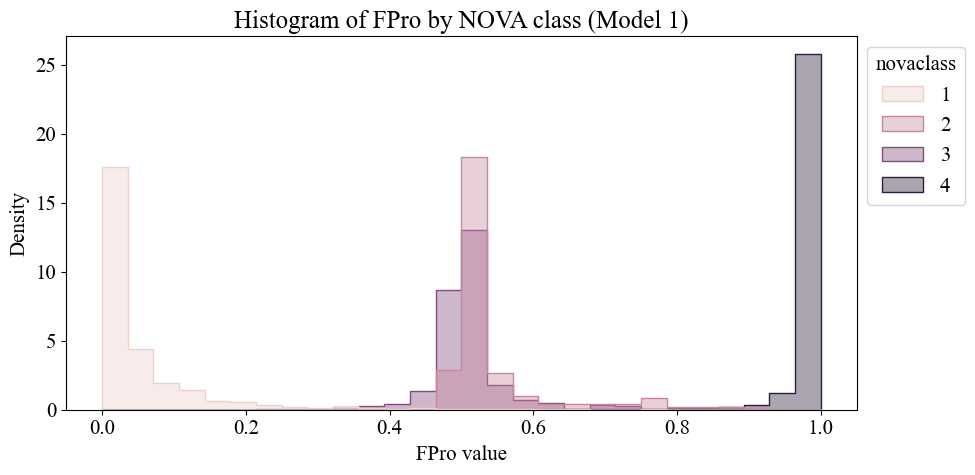

In [10]:
plt.figure(figsize=(10, 5)) 

ax = sns.histplot(
    data=dbAll_classified_1[dbAll_classified_1['novaclass']>0],
    x="FPro",
    hue="novaclass",
    stat="density",        
    common_norm=False,     
    element="step",       
    fill=True,             
    alpha=0.4,
    legend=True
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.xlabel("FPro value")
plt.ylabel("Density")
plt.title("Histogram of FPro by NOVA class (Model 1)")

plt.tight_layout()

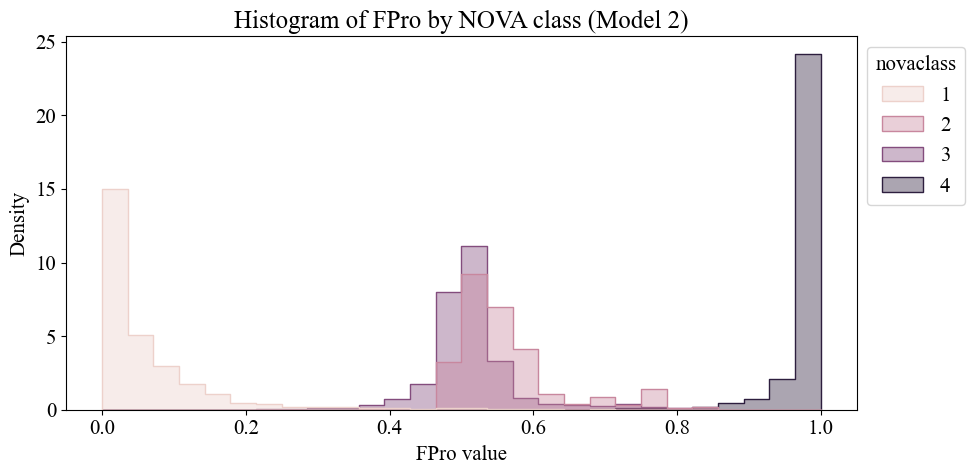

In [11]:
plt.figure(figsize=(10, 5)) 

ax = sns.histplot(
    data=dbAll_classified_2[dbAll_classified_2['novaclass']>0],
    x="FPro",
    hue="novaclass",
    stat="density",        
    common_norm=False,     
    element="step",       
    fill=True,             
    alpha=0.4,
    legend=True
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.xlabel("FPro value")
plt.ylabel("Density")
plt.title("Histogram of FPro by NOVA class (Model 2)")

plt.tight_layout()

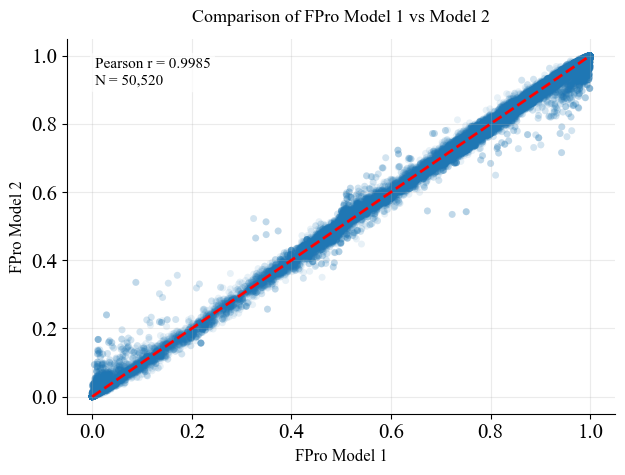

In [12]:
annotated_scatter_xy(
    x=dbAll_classified_1['FPro'],
    y=dbAll_classified_2['FPro'],
    xlabel="FPro Model 1",
    ylabel="FPro Model 2",
    title="Comparison of FPro Model 1 vs Model 2",
    alpha=0.10,
    s=25,
    add_identity=True
)

# Tailoring Models For Studies Building on NDSR data

https://www.ncc.umn.edu/products/

In [13]:
CommonNutrients=['Protein', 'Total Fat', 'Carbohydrate', 'Alcohol', 'Water',
    'Caffeine', 'Sugars, total', 'Fiber, total dietary',
    'Calcium', 'Iron', 'Magnesium', 'Phosphorus', 'Potassium',
    'Sodium', 'Zinc', 'Copper', 'Selenium', 'Retinol',
    'Carotene, beta', 'Carotene, alpha',
    'Vitamin E (alpha-tocopherol)', 'Cryptoxanthin, beta', 'Lycopene',
    'Lutein + zeaxanthin', 'Vitamin C', 'Thiamin', 'Riboflavin',
    'Niacin', 'Vitamin B-6', 'Folate, total', 'Vitamin B-12',
    'Vitamin K (phylloquinone)', 'Folic acid', 'Folate, food',
    'Cholesterol', 'Fatty acids, total saturated', '4:00', '6:00', '8:00',
    '10:00', '12:00', '14:00', '16:00', '18:00', '18:01', '18:02', '18:03',
    '20:04', '22:6 n-3', '16:01', '18:04', '20:01', '20:5 n-3', '22:01',
    '22:5 n-3', 'Fatty acids, total monounsaturated',
    'Fatty acids, total polyunsaturated']

In [14]:
len(CommonNutrients)

57

In [15]:
# Analysis of the duplicates according to different subsets of information
print("Unique on food description, food code, nova class, nutrients ", dbAll.drop_duplicates(subset=CommonNutrients+['Main food description', 'Food code','novaclass']).shape[0])
print("Unique on food code, nova class, nutrients ", dbAll.drop_duplicates(subset=CommonNutrients+['Food code','novaclass']).shape[0])
print("Unique on nova class, nutrients ", dbAll.drop_duplicates(subset=CommonNutrients+['novaclass']).shape[0])
print("Unique on nutrients ", dbAll.drop_duplicates(subset=CommonNutrients).shape[0])

Unique on food description, food code, nova class, nutrients  50520
Unique on food code, nova class, nutrients  50520
Unique on nova class, nutrients  41002
Unique on nutrients  39687


In [16]:
# unique full food profiles
dbAllSel_NDSR=dbAll.loc[:, CommonNutrients]
dbAllSel_NDSR['pythonlabel']=dbAll['pythonlabel']
data2train_NDSR=dbAllSel_NDSR.loc[dbAllSel_NDSR.pythonlabel!=-1, :]
X_NDSR=data2train_NDSR.loc[:, CommonNutrients].values
y_NDSR=data2train_NDSR['pythonlabel'].values

# without considering different product ids
dbAllSel_NDSRu=dbAll.drop_duplicates(subset=CommonNutrients+['novaclass']).loc[:, CommonNutrients]
dbAllSel_NDSRu['pythonlabel']=dbAll.drop_duplicates(subset=CommonNutrients+['novaclass'])['pythonlabel']
data2train_NDSRu=dbAllSel_NDSRu.loc[dbAllSel_NDSRu.pythonlabel!=-1, :]
X_NDSRu=data2train_NDSRu.loc[:, CommonNutrients].values
y_NDSRu=data2train_NDSRu['pythonlabel'].values

In [17]:
# unique full food profiles
params_defined={'n_estimators': 500, 'max_features': 'sqrt', 'max_depth': 20}
metrics_prefix="FoodProX_model_57_nutrients_unique_full_food_profiles"
params_file = os.path.join(model_dir, metrics_prefix+"_Params.pkl")
joblib.dump(params_defined, params_file)
metrics_prefix_prefile = os.path.join(metrics_dir, metrics_prefix)
cv_metrics_file = os.path.join(metrics_dir, metrics_prefix+"_CVmetrics.pkl")
models_prefix_file = os.path.join(model_dir,metrics_prefix)
fpro_prefix_file = os.path.join(outputs_dir,metrics_prefix)

training_splits_file= os.path.join(model_dir, "training_splits_unique_full_food_profiles_57_nutrients.pkl")
print(f"Using {X_NDSR.shape[0]} samples, {X_NDSR.shape[1]} dims, {len(np.unique(y_NDSR))} classes")

# Build 5 stratified folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

splits = []
for train_loc, test_loc in skf.split(X_NDSR, y_NDSR):
    splits.append({
        'train': train_loc.tolist(),
        'test':  test_loc.tolist()
    })

# Save those 5 splits as a pickled list of dicts
joblib.dump(splits, training_splits_file)
print(f"Saved 5 train/test splits → {training_splits_file}")

start_cv = time.time()
auc_3, aup_3, models_3 = AUCAUPkfold_from_file(
    X_NDSR, y_NDSR,
    model_type = 'RF',
    params_file=params_file,
    splits=splits,
    models_prefix=models_prefix_file,
    metrics_prefix=metrics_prefix_prefile,
    verbose=True
)

cv_time = time.time() - start_cv

print("CV Time ", cv_time )

cv_summary = {
    'auc_mean':  (auc_3.mean(), auc_3.std()),
    'auprc_mean':(aup_3.mean(), aup_3.std())
}


joblib.dump(cv_summary, cv_metrics_file)

dbAll_classified_3= classify_db(db=dbAll.loc[:, ['Food code', 'Main food description', 'DB', 'FNDDS_year', 'SR_version','novaclass']+CommonNutrients], model_per_fold=models_3, nut_sel=CommonNutrients)
dbAll_classified_3.to_csv(fpro_prefix_file+'.csv', index=False)

Using 18883 samples, 57 dims, 4 classes
Saved 5 train/test splits → Models_GitHub/training_splits_unique_full_food_profiles_57_nutrients.pkl
AUC mean: [0.99697067 0.99314516 0.99573063 0.99625699]
AUC std:  [0.00091392 0.00673852 0.00091826 0.00059829]
AUP mean: [0.99005587 0.93540874 0.97155428 0.9982293 ]
AUP std:  [0.00153564 0.01000336 0.00586944 0.00043533]
CV Time  7.357393741607666


In [18]:
# without considering different product ids
params_defined={'n_estimators': 500, 'max_features': 'sqrt', 'max_depth': 20}
metrics_prefix="FoodProX_model_57_nutrients_unique_nova_nutrients_pairs"
params_file = os.path.join(model_dir, metrics_prefix+"_Params.pkl")
joblib.dump(params_defined, params_file)

metrics_prefix_prefile = os.path.join(metrics_dir, metrics_prefix)
cv_metrics_file = os.path.join(metrics_dir, metrics_prefix+"_CVmetrics.pkl")
models_prefix_file = os.path.join(model_dir,metrics_prefix)
fpro_prefix_file = os.path.join(outputs_dir,metrics_prefix)

training_splits_file= os.path.join(model_dir, "training_splits_unique_nova_nutrients_pairs_57_nutrients.pkl")
print(f"Using {X_NDSRu.shape[0]} samples, {X_NDSRu.shape[1]} dims, {len(np.unique(y_NDSRu))} classes")

# Build 5 stratified folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

splits = []
for train_loc, test_loc in skf.split(X_NDSRu, y_NDSRu):
    splits.append({
        'train': train_loc.tolist(),
        'test':  test_loc.tolist()
    })

# Save those 5 splits as a pickled list of dicts
joblib.dump(splits, training_splits_file)
print(f"Saved 5 train/test splits → {training_splits_file}")

start_cv = time.time()
auc_4, aup_4, models_4 = AUCAUPkfold_from_file(
    X_NDSRu, y_NDSRu,
    model_type = 'RF',
    params_file=params_file,
    splits=splits,
    models_prefix=models_prefix_file,
    metrics_prefix=metrics_prefix_prefile,
    verbose=True
)

cv_time = time.time() - start_cv

print("CV Time ", cv_time )

cv_summary = {
    'auc_mean':  (auc_4.mean(), auc_4.std()),
    'auprc_mean':(aup_4.mean(), aup_4.std())
}

joblib.dump(cv_summary, cv_metrics_file)

dbAll_classified_4= classify_db(db=dbAll.loc[:, ['Food code', 'Main food description', 'DB', 'FNDDS_year', 'SR_version','novaclass']+CommonNutrients], model_per_fold=models_4, nut_sel=CommonNutrients)
dbAll_classified_4.to_csv(fpro_prefix_file+'.csv', index=False)

Using 14088 samples, 57 dims, 4 classes
Saved 5 train/test splits → Models_GitHub/training_splits_unique_nova_nutrients_pairs_57_nutrients.pkl
AUC mean: [0.9952447  0.98679443 0.99262697 0.99397451]
AUC std:  [0.00078428 0.01540172 0.00147302 0.00088551]
AUP mean: [0.9867922  0.86726949 0.95102876 0.99669702]
AUP std:  [0.00192065 0.05789379 0.01348623 0.00069724]
CV Time  6.313436985015869


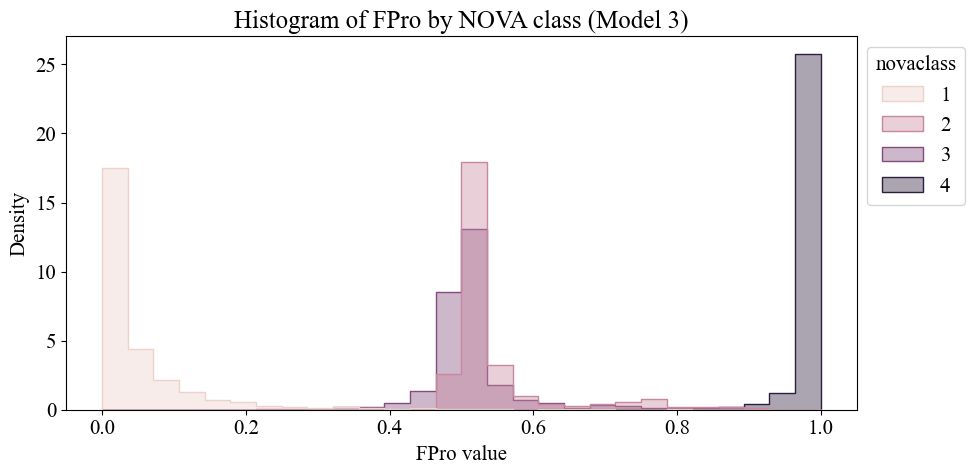

In [19]:
plt.figure(figsize=(10, 5)) 

ax = sns.histplot(
    data=dbAll_classified_3[dbAll_classified_3['novaclass']>0],
    x="FPro",
    hue="novaclass",
    stat="density",        
    common_norm=False,     
    element="step",       
    fill=True,             
    alpha=0.4,
    legend=True
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.xlabel("FPro value")
plt.ylabel("Density")
plt.title("Histogram of FPro by NOVA class (Model 3)")

plt.tight_layout()

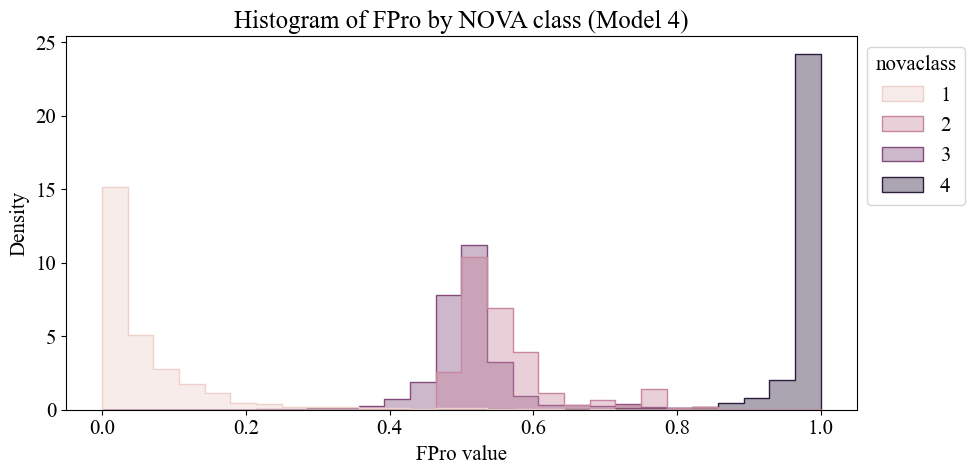

In [20]:
plt.figure(figsize=(10, 5)) 

ax = sns.histplot(
    data=dbAll_classified_4[dbAll_classified_4['novaclass']>0],
    x="FPro",
    hue="novaclass",
    stat="density",        
    common_norm=False,     
    element="step",       
    fill=True,             
    alpha=0.4,
    legend=True
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.xlabel("FPro value")
plt.ylabel("Density")
plt.title("Histogram of FPro by NOVA class (Model 4)")

plt.tight_layout()

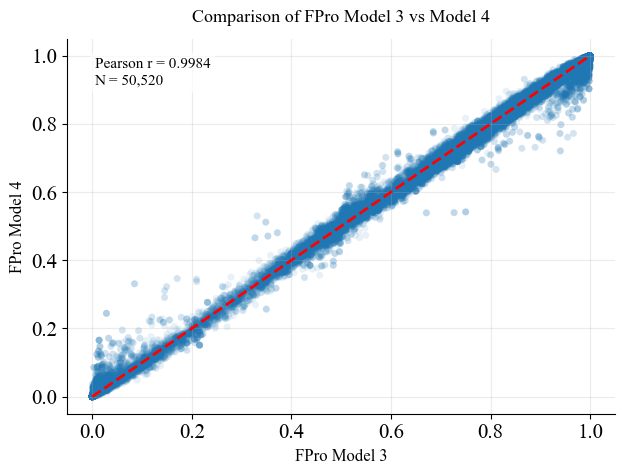

In [21]:
annotated_scatter_xy(
    x=dbAll_classified_3['FPro'],
    y=dbAll_classified_4['FPro'],
    xlabel="FPro Model 3",
    ylabel="FPro Model 4",
    title="Comparison of FPro Model 3 vs Model 4",
    alpha=0.10,
    s=25,
    add_identity=True
)

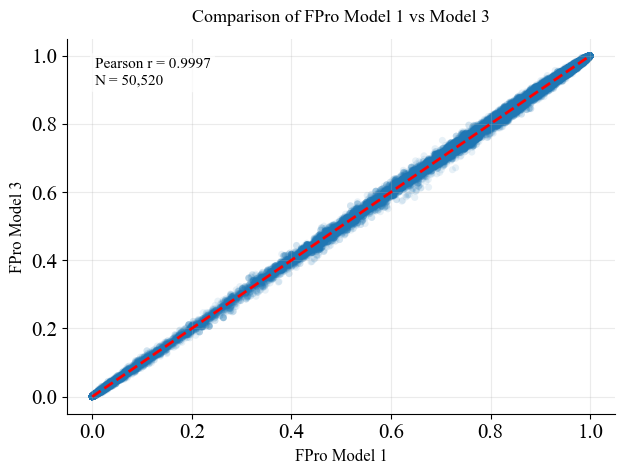

In [22]:
annotated_scatter_xy(
    x=dbAll_classified_1['FPro'],
    y=dbAll_classified_3['FPro'],
    xlabel="FPro Model 1",
    ylabel="FPro Model 3",
    title="Comparison of FPro Model 1 vs Model 3",
    alpha=0.10,
    s=25,
    add_identity=True
)